# The "Broken" Weather Station

Background: A mountain weather station has been offline for months and recently sent a burst of messy data. Before we can use the data and connect it to streamflow, it must be repaired and the Pandas toolkit can support this.

## Task 1: The Raw Feed 
Load the .csv of rainfall values and convert into a Pandas DataFrame named Rainfall_mm. The data can be found here:

```data/snotel_rainfall_data.csv```

Check your work: Use .head() and .describe(). Does the data look right?


In [3]:
import pandas as pd

Rainfall_in = pd.read_csv('data/snotel_rainfall_data.csv')
Rainfall_in.head()
Rainfall_in.describe()

,Date,Precip_in
count,61,58
unique,60,32
top,2024-01-16,0.0
freq,2,27


In [ ]:
Rainfall_in.head(20)

## Task 2: Using Pandas Tools to make the data readable

**coerce** turns anything it can't read as a number (like 'T' or 'error') into NaN


```df['colname'] = pd.to_numeric(df['colname'], errors='coerce')```

Apply this to your dataset and then try .describe()

In [4]:
# Convert 'Precip_in' to numeric, coercing errors to NaN
Rainfall_in['Precip_in'] = pd.to_numeric(Rainfall_in['Precip_in'], errors='coerce')
Rainfall_in['Precip_in'].describe()

count     56.000000
mean      -8.467089
std      150.395286
min     -999.000000
25%        0.000000
50%        0.050563
75%        0.682890
max      500.000000
Name: Precip_in, dtype: float64

In [34]:
Rainfall_in.head(20)

,Date,Precip_in
0,2024-01-01,0.140280
1,2024-01-02,0.659018
2,2024-01-03,0.000000
3,2024-01-04,0.000000
4,2024-01-05,0.375729
5,2024-01-06,0.000000
6,2024-01-07,1.095458
7,2024-01-08,0.000000
8,2024-01-09,0.000000
9,2024-01-10,0.186576


## Task 3: Load the discharge data

Load the .csv of rainfall values and convert into a Pandas Dataframe named streamflow_cfs. The data can be found here:

```data/streamflow_data.csv```

Check your work: Use .head() and .describe(). Does the data look right? How can you extract more useful statistics? Show this.

In [5]:
# Convert 'Streamflow_cfs' to numeric, coercing errors to NaN
streamflow = pd.read_csv('data/streamflow_data.csv')
streamflow['Streamflow_cfs'] = pd.to_numeric(streamflow['Streamflow_cfs'], errors='coerce')
streamflow['Streamflow_cfs'].describe()
streamflow.head(61)

,Date,Streamflow_cfs
0,2024-01-01,10.25
1,2024-01-02,10.70
2,2024-01-03,13.30
3,2024-01-04,10.10
4,2024-01-05,10.00
5,2024-01-06,11.90
6,2024-01-07,10.00
7,2024-01-08,15.50
8,2024-01-09,10.15
9,2024-01-10,10.45


## Task 4: Clean and repair the data

The sensor cut out during the storm and we now have NaN **AND** -999 values. This prevents us from plotting or otherwise using the time series. Are there any other values we should remove?

Explore different methods and select one that fits the data.

Explore .dropna() (delete the gap), .fillna() with the mean, and .interpolate() for a smoother hydrograph for both datasets.

Note, it may be useful to create a new Pandas DataFrame to compare differences. 

In [53]:
import numpy as np

#clean missing values
streamflow_clean = streamflow.copy()
streamflow_clean.loc[(streamflow_clean['Streamflow_cfs'] <0) | (streamflow_clean['Streamflow_cfs'] >25),  'Streamflow_cfs' ]= pd.NA
streamflow_fill = streamflow_clean['Streamflow_cfs'].fillna(streamflow_clean['Streamflow_cfs'].mean())
streamflow_drop = streamflow_clean['Streamflow_cfs'].dropna()
streamflow_interpolate = streamflow_clean['Streamflow_cfs'].interpolate(method='linear')

#One combine read out

streamflow_methods = pd.DataFrame({
    'Date':streamflow['Date'],
    'Original': streamflow['Streamflow_cfs'],
    'Drop': streamflow_drop.reindex(streamflow.index),
    'Fill_Mean': streamflow_fill,
    'Interpolate': streamflow_interpolate
})

print(streamflow_methods)

#clean rainfall data
Rainfall_clean = Rainfall_in.copy()
Rainfall_clean.loc[(Rainfall_clean['Precip_in'] <0) | (Rainfall_clean['Precip_in'] > 5), 'Precip_in'] = pd.NA
Rainfall_fill = Rainfall_clean['Precip_in'].fillna(Rainfall_clean['Precip_in'].mean())
Rainfall_drop = Rainfall_clean['Precip_in'].dropna()
Rainfall_interpolate = Rainfall_clean['Precip_in'].interpolate(method='linear')
Rainfall_clean.head(20)

rainfall_methods = pd.DataFrame({
    'date': Rainfall_in['Date'],
    'Original': Rainfall_in['Precip_in'],
    'Drop': Rainfall_drop.reindex(Rainfall_in.index), 
    'Fill_Mean': Rainfall_fill,
    'Interpolate': Rainfall_interpolate
})

print(rainfall_methods)



          Date  Original   Drop  Fill_Mean  Interpolate
0   2024-01-01     10.25  10.25  10.250000       10.250
1   2024-01-02     10.70  10.70  10.700000       10.700
2   2024-01-03     13.30  13.30  13.300000       13.300
3   2024-01-04     10.10  10.10  10.100000       10.100
4   2024-01-05     10.00  10.00  10.000000       10.000
5   2024-01-06     11.90  11.90  11.900000       11.900
6   2024-01-07     10.00  10.00  10.000000       10.000
7   2024-01-08     15.50  15.50  15.500000       15.500
8   2024-01-09     10.15  10.15  10.150000       10.150
9   2024-01-10     10.45  10.45  10.450000       10.450
10  2024-01-11       NaN    NaN  12.259804       10.700
11  2024-01-12       NaN    NaN  12.259804       10.950
12  2024-01-13       NaN    NaN  12.259804       11.200
13  2024-01-14       NaN    NaN  12.259804       11.450
14  2024-01-15       NaN    NaN  12.259804       11.700
15  2024-01-16     11.95  11.95  11.950000       11.950
16  2024-01-17     10.00  10.00  10.000000      

## Task 5: Join Pandas DataFrames

We often want to relate data to another, and having all the data in once centralized data frame supports this comparison. Create a new Pandas DataFrame named:
* rainfall_methods fill it with the three rainfall dataframes we cleaned
* streamflow_methods and fill it with the three streamflow dataframes we cleaned


In [49]:
#Join 3 rainfall and 3 streamflow methods into two dataframes

# Rainfall_combined = pd.DataFrame({
rainfall_combined = rainfall_methods.drop(columns='Original').copy()


#Streamflow_combined = pd.DataFrame({
streamflow_combined = streamflow_methods.drop(columns='Original').copy()


print(rainfall_combined)
print(streamflow_combined)

          date      Drop  Fill_Mean  Interpolate
0   2024-01-01  0.140280   0.140280     0.140280
1   2024-01-02  0.659018   0.659018     0.659018
2   2024-01-03  0.000000   0.000000     0.000000
3   2024-01-04  0.000000   0.000000     0.000000
4   2024-01-05  0.375729   0.375729     0.375729
..         ...       ...        ...          ...
56  2024-02-25       NaN   0.460056     1.019595
57  2024-02-26  1.609937   1.609937     1.609937
58  2024-02-27  0.954725   0.954725     0.954725
59  2024-02-28  0.101126   0.101126     0.101126
60  2024-02-29  0.000000   0.000000     0.000000

[61 rows x 4 columns]
          Date   Drop  Fill_Mean  Interpolate
0   2024-01-01  10.25  10.250000       10.250
1   2024-01-02  10.70  10.700000       10.700
2   2024-01-03  13.30  13.300000       13.300
3   2024-01-04  10.10  10.100000       10.100
4   2024-01-05  10.00  10.000000       10.000
5   2024-01-06  11.90  11.900000       11.900
6   2024-01-07  10.00  10.000000       10.000
7   2024-01-08  15.50

## Task 6: Plot the rainfall and streamflow data to visualize trends and relationships.

Use Pandas simple plotting functionality to separately plot the two dataframes. Which interpolation method do you like? 

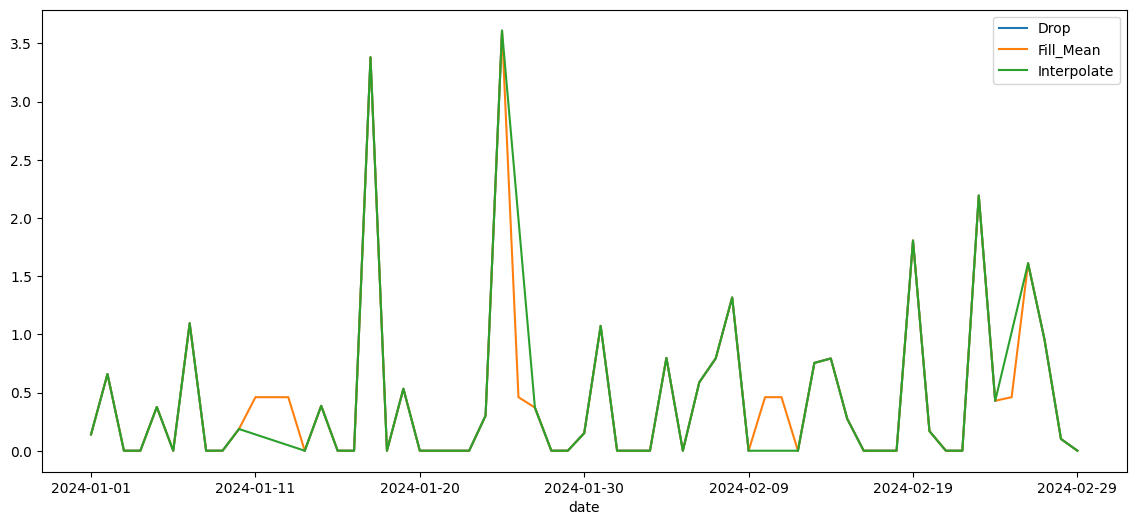

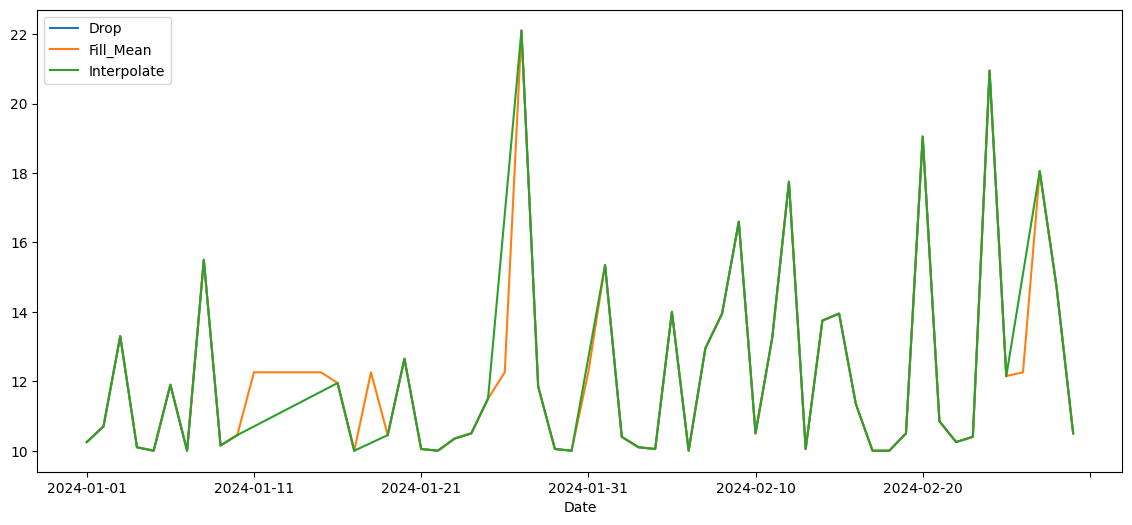

In [50]:
#Plot The three variables in both rainfall_combined and streamflow_combined

# Plot
rainfall_combined.plot(x='date', y=['Drop', 'Fill_Mean', 'Interpolate'], figsize=(14, 6))
plt.show()

streamflow_combined.plot(x='Date', y=['Drop', 'Fill_Mean', 'Interpolate'], figsize=(14, 6))
plt.show()

## Task 7: Combining DataFrames

From the plots above, choose your most representative gap filling dataframe for rainfall and streamflow, and combine them into a rain_flow_df DataFrame.

In [58]:
#Combining dataframes with more representative gap filling methods (e.g., interpolation) and plotting them together to see the relationship between rainfall and streamflow over time.
Combine = pd.DataFrame({
    'date': Rainfall_in['Date'],
    'Rainfall_Interpolate': Rainfall_interpolate,
    'Streamflow_Interpolate': streamflow_interpolate
})

print(Combine)


          date  Rainfall_Interpolate  Streamflow_Interpolate
0   2024-01-01              0.140280                   10.25
1   2024-01-02              0.659018                   10.70
2   2024-01-03              0.000000                   13.30
3   2024-01-04              0.000000                   10.10
4   2024-01-05              0.375729                   10.00
..         ...                   ...                     ...
56  2024-02-25              1.019595                   15.10
57  2024-02-26              1.609937                   18.05
58  2024-02-27              0.954725                   14.75
59  2024-02-28              0.101126                   10.50
60  2024-02-29              0.000000                     NaN

[61 rows x 3 columns]


## Task 8: Calculate the monthly statistics of the rainfall and discharge

Calculate the monthly total, mean daily (for each month), and the maximum (for each month) rainfall and flow. 

In [60]:
#Calculate the  and maximum for each month for both rainfall and streamflow.Date

#Calculate the monthly total for rainfall and streamflow
Rainfall_monthly_total = Combine.groupby(Combine['date'].str[:7])['Rainfall_Interpolate'].sum()
Streamflow_monthly_total = Combine.groupby(Combine['date'].str[:7])['Streamflow_Interpolate'].sum()
print("Monthly Total Rainfall:")
print(Rainfall_monthly_total)
print("\nMonthly Total Streamflow:")
print(Streamflow_monthly_total)

#Calculate the mean daily for each month for rainfall and streamflow
Rainfall_monthly_mean = Combine.groupby(Combine['date'].str[:7])['Rainfall_Interpolate'].mean()
Streamflow_monthly_mean = Combine.groupby(Combine['date'].str[:7])['Streamflow_Interpolate'].mean()
print("Monthly Mean Rainfall:")
print(Rainfall_monthly_mean)
print("\nMonthly Mean Streamflow:")
print(Streamflow_monthly_mean)

#Calculate the maximum daily for each month for rainfall and streamflow
Rainfall_monthly_max = Combine.groupby(Combine['date'].str[:7])['Rainfall_Interpolate'].max()
Streamflow_monthly_max = Combine.groupby(Combine['date'].str[:7])['Streamflow_Interpolate'].max()
print("Monthly Max Rainfall:")
print(Rainfall_monthly_max)
print("\nMonthly Max Streamflow:")
print(Streamflow_monthly_max)   

Monthly Total Rainfall:
date
2024-01    14.531730
2024-02    13.600824
Name: Rainfall_Interpolate, dtype: float64

Monthly Total Streamflow:
date
2024-01    374.85
2024-02    361.20
Name: Streamflow_Interpolate, dtype: float64
Monthly Mean Rainfall:
date
2024-01    0.454117
2024-02    0.468994
Name: Rainfall_Interpolate, dtype: float64

Monthly Mean Streamflow:
date
2024-01    11.714063
2024-02    12.900000
Name: Streamflow_Interpolate, dtype: float64
Monthly Max Rainfall:
date
2024-01    3.609354
2024-02    2.193069
Name: Rainfall_Interpolate, dtype: float64

Monthly Max Streamflow:
date
2024-01    22.10
2024-02    20.95
Name: Streamflow_Interpolate, dtype: float64


## Task 9: Data Corrections

We want to put the data into a streamflow model, but it requires precipitation to be in mm and streamflow to be in CMS (cubic meters per second). Create a new dataframe called rain_flow_SI_df that converts the previous dataframe to SI units.

In [62]:
#Create a new dataframe that converts precipitation from inches to millimeters and streamflow from cubic feet per second to cubic meters per second.
rain_flow_SI_df = pd.DataFrame({
    'date': Combine['date'],
    'Precip_mm': Combine['Rainfall_Interpolate'] * 25.4,  # Convert inches to millimeters
    'Streamflow_m3s': Combine['Streamflow_Interpolate'] * 0.0283168  # Convert cubic feet per second to cubic meters per second
})

print(rain_flow_SI_df)

          date  Precip_mm  Streamflow_m3s
0   2024-01-01   3.563120        0.290247
1   2024-01-02  16.739058        0.302990
2   2024-01-03   0.000000        0.376613
3   2024-01-04   0.000000        0.286000
4   2024-01-05   9.543520        0.283168
..         ...        ...             ...
56  2024-02-25  25.897710        0.427584
57  2024-02-26  40.892412        0.511118
58  2024-02-27  24.250028        0.417673
59  2024-02-28   2.568606        0.297326
60  2024-02-29   0.000000             NaN

[61 rows x 3 columns]


## Task 10: Event diagnostics

A key element of hydroinformatics is to identify key events and learn from them. Here, we have two tasks.
* Create a new column and programatically label each day as 'Dry', 'Light Rain', or 'Heavy Rain' based on the precipitaiton colum.
* From our rain_flow_SI_df, create a new Pandas DataFrame called storm_df that programatically selects the streamflow and precipitation data for 5 days before and after the peak flow event.

In [66]:
#Create a new column to label each day as Dry, Light Rain, or Heavy rain
def label_rainfall(precip):
    if precip == 0:
        return 'Dry'
    elif precip < 0.1:
        return 'Light Rain'
    else:
        return 'Heavy Rain'
    
rain_flow_SI_df['Rainfall_Label'] = rain_flow_SI_df['Precip_mm'].apply(label_rainfall)
#print(rain_flow_SI_df)

#Create a new Pandas dataframe called storm_df that selects streamflow and precip for 5 days before and after the peak flow event.
# Identify the date of the peak flow event
peak_flow_date = rain_flow_SI_df.loc[rain_flow_SI_df['Streamflow_m3s'].idxmax(), 'date']
# Convert the date column to datetime format
rain_flow_SI_df['date'] = pd.to_datetime(rain_flow_SI_df['date'])
# Create a new dataframe for the storm event
storm_df = rain_flow_SI_df[(rain_flow_SI_df['date'] >= peak_flow_date - pd.Timedelta(days=5)) & (rain_flow_SI_df['date'] <= peak_flow_date + pd.Timedelta(days=5))]
print(storm_df)  

         date  Precip_mm  Streamflow_m3s Rainfall_Label
21 2024-01-21   0.000000        0.283168            Dry
22 2024-01-22   0.000000        0.293079            Dry
23 2024-01-23   0.000000        0.297326            Dry
24 2024-01-24   7.656654        0.325643     Heavy Rain
25 2024-01-25  91.677590        0.475722     Heavy Rain
26 2024-01-26  50.548266        0.625801     Heavy Rain
27 2024-01-27   9.418942        0.335554     Heavy Rain
28 2024-01-28   0.000000        0.284584            Dry
29 2024-01-29   0.000000        0.283168            Dry
30 2024-01-30   3.837179        0.358915     Heavy Rain
31 2024-01-31  27.246213        0.434663     Heavy Rain


## Task 11: Quick Data Visualziation

Use the pandas plot function to conduct a quick visualization of precipitation and streamflow. Do they seem coorelated? Any glaring errors?

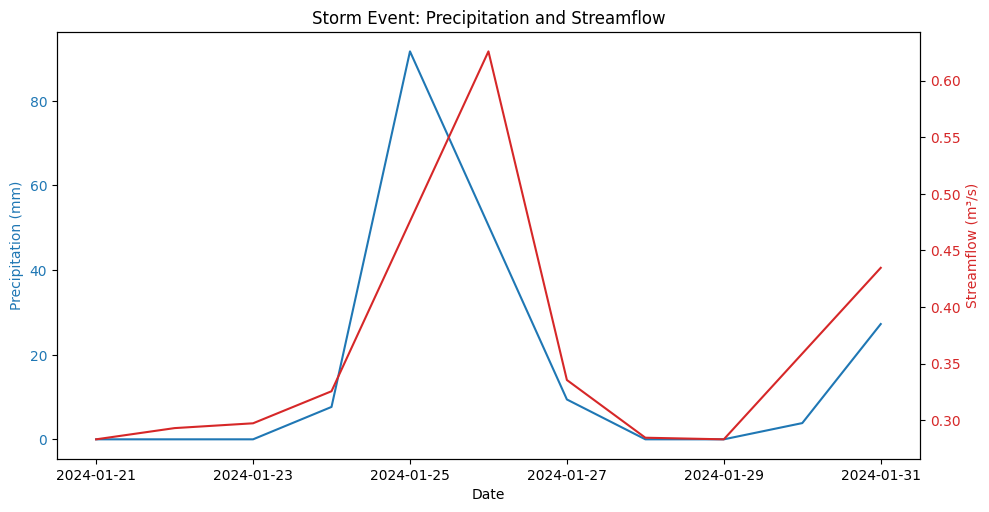

In [68]:
#Create a quick pandas plot of the storm event showing both rainfall and streamflow on the same graph with two y-axes.

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel('Date')
ax1.set_ylabel('Precipitation (mm)', color='tab:blue')
ax1.plot(storm_df['date'], storm_df['Precip_mm'], color='tab:blue', label='Precipitation (mm)')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
ax2.set_ylabel('Streamflow (m³/s)', color='tab:red')  #
ax2.plot(storm_df['date'], storm_df['Streamflow_m3s'], color='tab:red', label='Streamflow (m³/s)')
ax2.tick_params(axis='y', labelcolor='tab:red')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Storm Event: Precipitation and Streamflow')
plt.show()

It seems that they are relatively well correlated for the main storm event, but then streamflow rises for no reason at the end of the plot which is probably an error.